In [13]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 150

In [14]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
source = "casesm2_10km_nocumulus"
# source = "IMERGv7"

# MCS masks
root_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs_masks/"
in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
in_zarr

# # Combined all feature masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
# in_zarr

'/pscratch/sd/w/wcmca1/hackathon/mcs_masks/casesm2_10km_nocumulus_mcs_masks_hp8.zarr'

In [15]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 9GB
Dimensions:      (cell: 786432, time: 1461)
Coordinates:
  * cell         (cell) int64 6MB 0 1 2 3 4 ... 786428 786429 786430 786431
    crs          int64 8B ...
  * time         (time) datetime64[ns] 12kB 2020-03-01 ... 2021-03-01
Data variables:
    cloud_types  (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
    mcs_mask     (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
Attributes: (12/18)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Fri Jul 18 10:34:12 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    processing_script:         make_mcs_swath_masks.py
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [16]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2020-03-01T00:00:00.000000000', '2020-03-01T06:00:00.000000000',
       '2020-03-01T12:00:00.000000000', '2020-03-01T18:00:00.000000000',
       '2020-03-02T00:00:00.000000000', '2020-03-02T06:00:00.000000000',
       '2020-03-02T12:00:00.000000000', '2020-03-02T18:00:00.000000000',
       '2020-03-03T00:00:00.000000000', '2020-03-03T06:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
  * time     (time) datetime64[ns] 80B 2020-03-01 ... 2020-03-03T06:00:00
Attributes:
    long_name:  Base time in Epoch

In [17]:
ds.mcs_mask.attrs

{'comment': 'Track numbers are assigned by PyFLEXTRKR. Overlapping tracks resolved by highest coverage count.',
 'description': 'MCS track swath mask aggregated over time window. Each pixel labeled with MCS track number.',
 'grid_mapping': 'crs',
 'long_name': 'MCS swath mask',
 'units': '1',
 'valid_range': [0, 1000000]}

In [18]:
ds.cloud_types.attrs

{'comment': 'Classification based on brightness temperature and precipitation rate. Priority for ties: 1>2>3>4.',
 'description': 'Most frequent cloud type within non-MCS cold cloud shield over time window',
 'flag_meanings': 'no_cloud deep_convective stratiform non_deep_convective drizzle',
 'flag_values': [0, 1, 2, 3, 4],
 'grid_mapping': 'crs',
 'long_name': 'Cloud type classification',
 'units': '1',
 'valid_range': [0, 4]}

<Figure size 960x720 with 0 Axes>

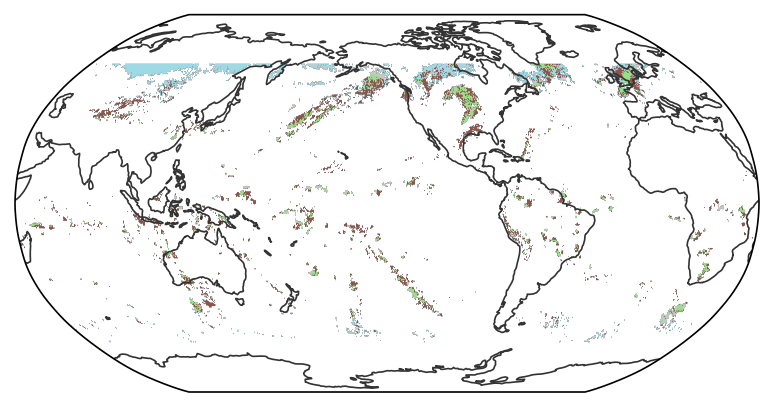

In [19]:
itime = 1401
# itime = 1201
cloud_types = ds.cloud_types.isel(time=itime)
egh.healpix_show(cloud_types.where(cloud_types > 0), vmin=0, vmax=4, cmap='tab20')

<Figure size 960x720 with 0 Axes>

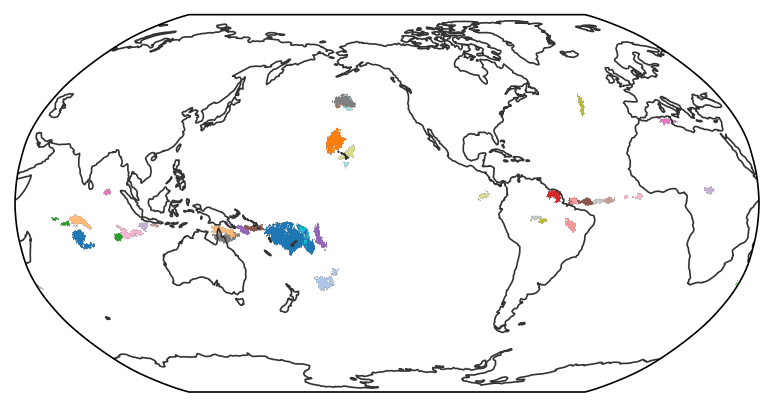

In [20]:
# itime = 1021
itime = 1
mcs_mask = ds.mcs_mask.isel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

In [21]:
sdate = '2020-03-01T00'
edate = '2020-03-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 960x720 with 0 Axes>

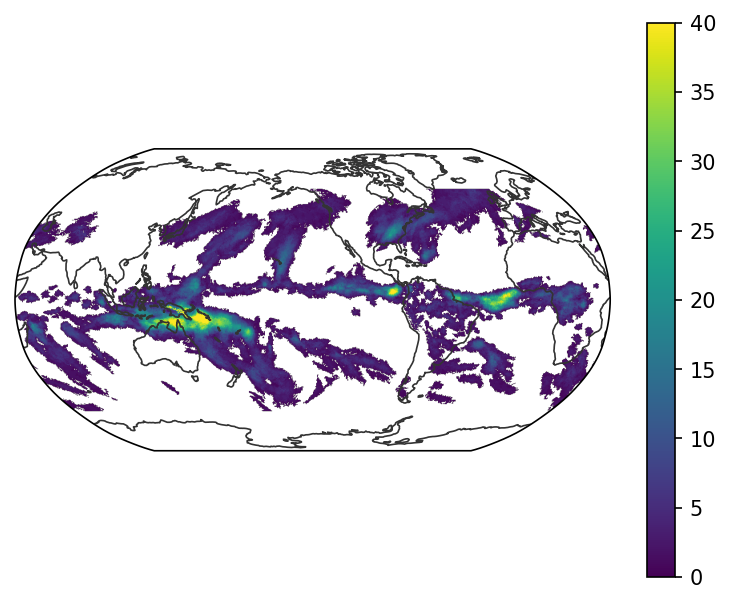

In [22]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [23]:
mcs_freq.max().values

array(62.09677419)